# EDA 

In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/telco_churn.csv')

df.info()
df.describe(include='all')
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# TotalCharges deveria ser numérico, mas veio como string. Primeiro vejamos os valores problemáticos:

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remover as 11 linhas com TotalCharges inválido (tenure=0, clientes sem cobrança registrada)
n_before = len(df)
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f"Linhas removidas: {n_before - len(df)} | Total restante: {len(df)}")

# Possui valores nulos?

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Possui valores invalidos? 

In [ ]:
# Linhas onde TotalCharges é espaço vazio (não convertível para número)
mask_invalid = df['TotalCharges'].str.strip() == ''
print(f"Linhas com TotalCharges inválido: {mask_invalid.sum()}")
df[mask_invalid][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

# Validar distribuição e entender o dataset

Aonde tem muitos outlier

In [ ]:
df.describe()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

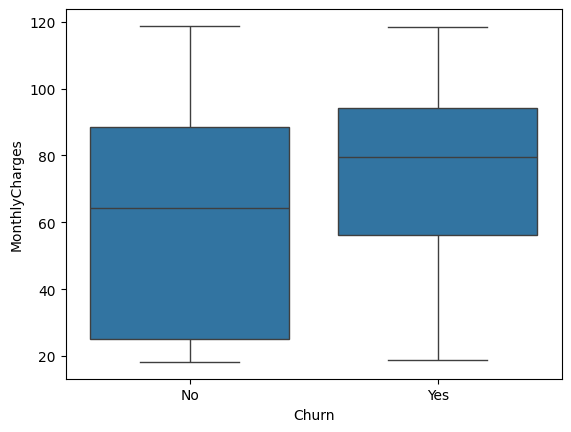

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

# Validar com uma linha crescente 

(quanto maior o tempo, maior o total)
 clientes churn (Yes) concentrados em:
 - baixo tenure
 - baixo total

clientes novos estão cancelando antes de gerar valor

tenure : quanto tempo o cliente está na empresa (meses)
TotalCharges : quanto ele já pagou no total

TotalCharges ≈ tenure × MonthlyCharges

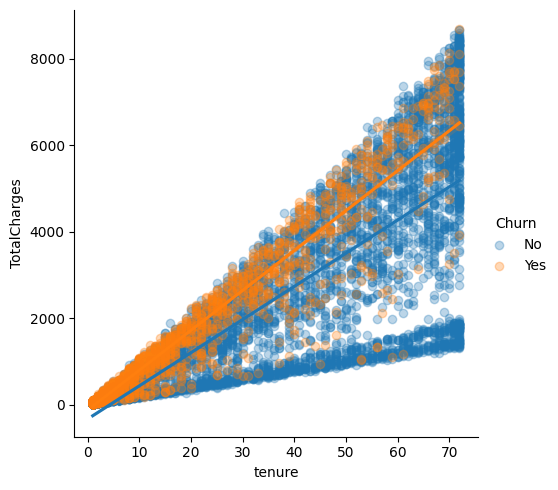

In [36]:
import seaborn as sns

sns.lmplot(
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    data=df,
    scatter_kws={'alpha':0.3}
)

- Clientes com planos baratos que ficam muito tempo
- Clientes que cancelam (laranja) estão, em média, em planos mais caros.

# Validar Categorias inconsistentes 

In [26]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

# Churn rate por variável categórica

Quais categorias têm maior taxa de cancelamento? Isso revela os perfis de risco antes de qualquer modelo.

NameError: name 'df' is not defined

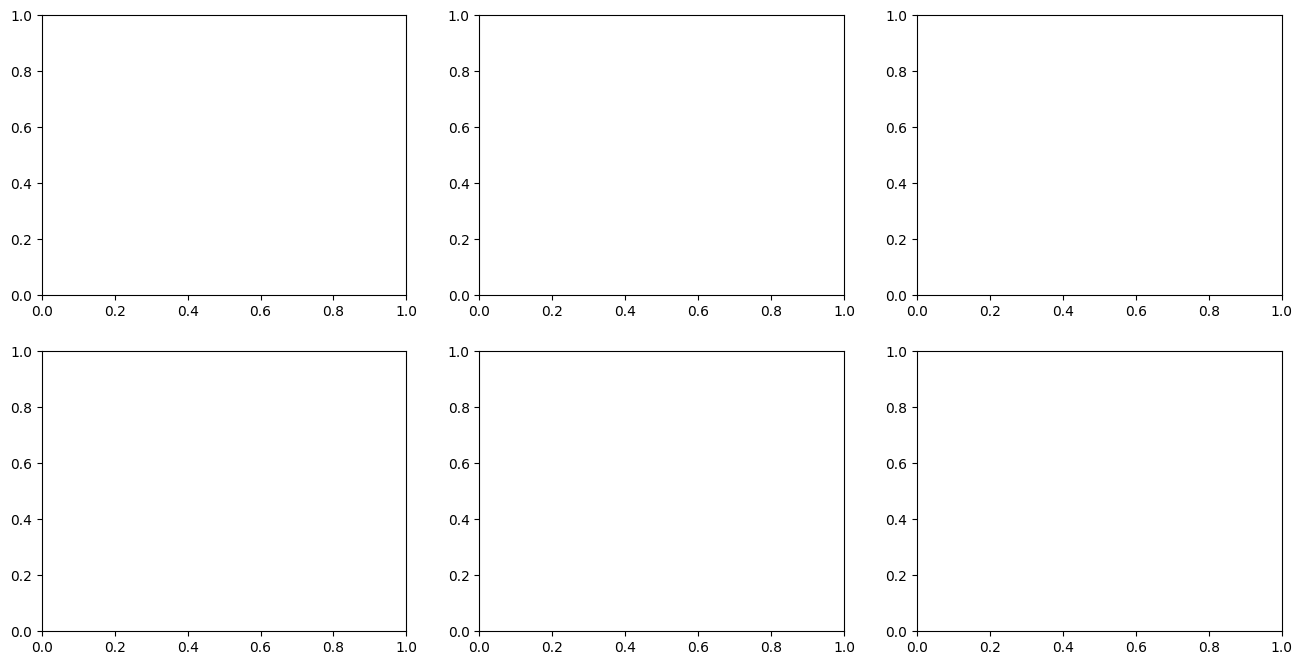

In [1]:

cat_features = [
    'Contract', 'InternetService', 'PaymentMethod',
    'TechSupport', 'OnlineSecurity', 'MultipleLines'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    churn_rate = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
    )
    colors = ['tomato' if v > 30 else 'steelblue' for v in churn_rate.values]
    bars = ax.bar(churn_rate.index, churn_rate.values, color=colors, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Churn rate (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(y=df['Churn'].eq('Yes').mean() * 100, color='gray', linestyle='--', linewidth=1, label='média geral')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[-1].legend(loc='upper right')
plt.suptitle('Churn rate por categoria — vermelho = risco acima de 30%', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Validar colunas inuteis

- customerID é desnecessario

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

#  Data Readiness — O dataset está pronto para o modelo?

Nesta seção as perguntas críticas antes de qualquer treinamento.

## 🔹 1. Encoding necessário

Variáveis categóricas precisam ser convertidas para número antes do modelo.
- Binárias (`Yes`/`No`, `Male`/`Female`): Label Encoding
- Multi-classe (`PaymentMethod`, `Contract`, `InternetService`): One-Hot Encoding

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')
cat_cols.remove('Churn')

print("Colunas categóricas que precisam de encoding:\n")
for col in cat_cols:
    n_unique = df[col].nunique()
    values = df[col].unique().tolist()
    enc_type = "Label (binária)" if n_unique == 2 else "One-Hot"
    print(f"  {col:<20} | {n_unique} valores | {enc_type}")
    print(f"    → {values}\n")

## 🔹 2. Escala dos dados

`tenure`, `MonthlyCharges` e `TotalCharges` possuem escalas diferentes.
Modelos sensíveis a distância (regressão logística, SVM, KNN) exigem normalização.

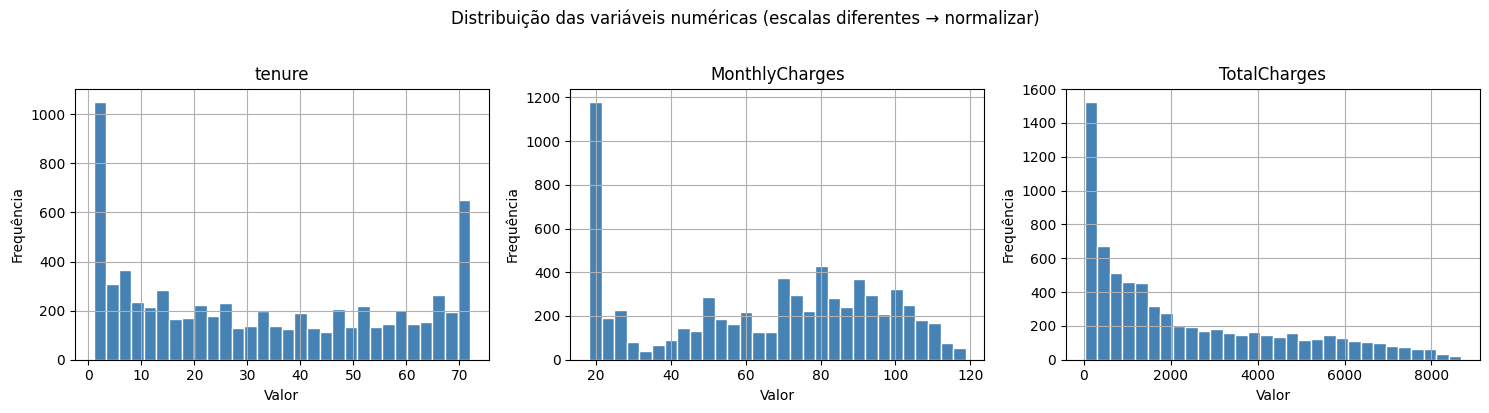


Estatísticas descritivas:


,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


In [46]:
import matplotlib.pyplot as plt

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')

plt.suptitle('Distribuição das variáveis numéricas (escalas diferentes → normalizar)', y=1.02)
plt.tight_layout()
plt.show()

print("\nEstatísticas descritivas:")
df[num_cols].describe().round(2)

## 🔹 3. Multicolinearidade

Suspeita: `TotalCharges ≈ tenure × MonthlyCharges`

Se a correlação for muito alta (> 0.9), `TotalCharges` pode ser redundante e causar instabilidade em modelos lineares.

Matriz de correlação:
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.247         0.826
MonthlyCharges   0.247           1.000         0.651
TotalCharges     0.826           0.651         1.000


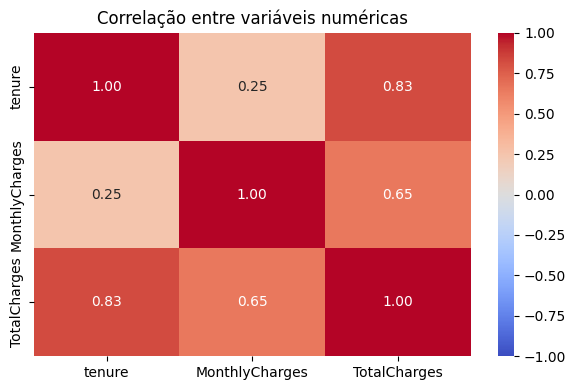


Correlação TotalCharges ~ tenure: 0.826


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
print("Matriz de correlação:")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

tc_corr = corr.loc['TotalCharges', 'tenure']
print(f"\nCorrelação TotalCharges ~ tenure: {tc_corr:.3f}")
if tc_corr > 0.9:
    print("⚠️  Alta multicolinearidade — considerar remover TotalCharges do modelo.")

## 🔹 4. Balanceamento do target (CRÍTICO)

Se o dataset estiver muito desbalanceado (ex: 80% No / 20% Yes), o modelo pode aprender a simplesmente prever sempre "No" e ainda assim ter alta acurácia.

Técnicas de mitigação: `class_weight='balanced'`, SMOTE, ou ajuste de threshold de decisão.

In [ ]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Distribuição do target (Churn):")
for label in churn_counts.index:
    print(f"  {label}: {churn_counts[label]} ({churn_pct[label]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Contagem absoluta')
axes[0].set_ylabel('Qtd clientes')
for i, (label, val) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, val + 30, str(val), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporção (%)')

plt.suptitle('Balanceamento do target — Churn', y=1.02)
plt.tight_layout()
plt.show()

ratio = churn_pct.max() / churn_pct.min()
print(f"\nRazão majoritária/minoritária: {ratio:.1f}x")
if ratio > 3:
    print("⚠️  Dataset desbalanceado — usar class_weight='balanced' ou técnicas de resampling.")

: 

## 🔹 5. Separação treino/teste

Estratégia de validação definida antes do treinamento para evitar data leakage.

- **Split:** 80% treino / 20% teste, estratificado por `Churn` (mantém proporção do target)
- **Seed:** 42 (reprodutibilidade)

In [ ]:
from sklearn.model_selection import train_test_split

cols_to_drop = [col for col in ['customerID', 'Churn'] if col in df.columns]
X = df.drop(columns=cols_to_drop)
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total:  {len(df):>5} amostras")
print(f"Treino: {len(X_train):>5} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Teste:  {len(X_test):>5} ({len(X_test)/len(df)*100:.1f}%)")
print()
print("Proporção do target no treino:")
print(y_train.value_counts(normalize=True).rename({1: 'Churn=Yes', 0: 'Churn=No'}).round(3))
print("\nProporção do target no teste:")
print(y_test.value_counts(normalize=True).rename({1: 'Churn=Yes', 0: 'Churn=No'}).round(3))

## 🔹 6. Formalização do problema de ML

| Item | Definição |
|------|-----------|
| **Tipo** | Classificação binária supervisionada |
| **Target** | `Churn` → `1` (cancelou) / `0` (não cancelou) |
| **Features** | 19 originais + 4 derivadas (`ChargesPerMonth`, `HighSpender`, `NewCustomer`, `LongTermCustomer`) |
| **Métrica de seleção (técnica)** | **PR-AUC** — robusta ao desbalanceamento, usada para ranquear modelos |
| **Métrica de operação (negócio)** | **Custo de churn evitado** — threshold ótimo minimiza `FN×10 + FP×1` (perder churner dói 10× mais que oferta desperdiçada) |
| **Métricas secundárias** | AUC-ROC, F1, Recall, Accuracy |
| **Baseline ingênuo** | Prever sempre `No` → acurácia ≈ 73%, mas Recall para churn = 0% |

----

> **Por que PR-AUC + custo, e não Accuracy ou Recall isolado?**
> - Com ~73% "No", um modelo que nunca prevê churn tem 73% de acurácia mas é inútil → Accuracy descartada como métrica primária.
> - Recall isolado pode ser maximizado prevendo "Yes" para todo mundo (recall=100%, precision péssima) → não serve sozinho.
> - **PR-AUC** mede o trade-off Precision×Recall na classe minoritária (churn) sem depender de threshold.
> - **Custo de negócio** (`FN×10 + FP×1`) traduz o trade-off em decisão operacional: vale 10 ofertas desperdiçadas para reter 1 churner.


## Conclusões do EDA

### Principais insights

- Clientes com baixo tenure apresentam maior taxa de churn (motiva a feature `NewCustomer = tenure ≤ 6`)
- Clientes que cancelam tendem a ter menor TotalCharges acumulado
- Existe forte correlação entre `tenure` e `TotalCharges` (r > 0.85), mas em vez de remover, criamos a feature derivada `ChargesPerMonth = TotalCharges / (tenure + 1)` para capturar o ticket médio histórico de outra forma
- Algumas categorias (ex.: contratos mensais) apresentam churn significativamente maior

### Implicações para o modelo

- Feature engineering adotada no pipeline final (`src/data.py`):
  - `ChargesPerMonth`, `HighSpender`, `NewCustomer`, `LongTermCustomer`
- Encoding: `pd.get_dummies(drop_first=True)` em todas as colunas object
- Multicolinearidade mitigada por regularização (LR `C=0.1`) e modelos não-lineares (XGBoost, MLP)

### Riscos identificados

- Dataset desbalanceado (~73/27) → métricas adequadas: **PR-AUC** (técnica) + **custo de negócio** (operacional)
- Custo de FN >> FP → threshold de operação é otimizado para minimizar `FN×10 + FP×1`

### Próximo passo

- `notebooks/Data-Readiness.ipynb` — auditoria completa antes do treino
- `notebooks/Baselines.ipynb` — Dummy, LR, DT, RF, XGBoost
- `src/main.py` — pipeline final: CV + baselines + MLP + ensemble
